## **Par MPOUAVOULI Rayde Prosperin**

## **Estimation des risques extrêmes : VAR et CVAR**

#### Les méthodes traditionnelles supposent une distribution normale des rendements, mais en réalité, les marchés financiers présentent souvent des queues épaisses (kurtosis élevé) et des  asymétries  (skewness), ce qui rend l'hypothèse gaussienne inadéquate pour estimer les risques extrêmes.


#### L'hypothèse gaussienne
#### Hypothèse de simplification standard
#### Les rendements des actifs sont normalement distribués.

### **Skewness**
##### Kewness (Asymétrie) : Mesure l'asymétrie de la distribution. Une skewness négative indique que les pertes extrêmes sont plus probables que les gains extrêmes.

$\text{Skewness} = \frac{1}{n}\sum_{i=1}^{n}\left(\frac{x_i - \bar{x}}{s}\right)^3$

In [21]:
from scipy.stats import skew
skewness_df =pd.DataFrame(skew(hfi), index=hfi.columns, columns=["Skewness"])
skewness_df

,Skewness
Convertible Arbitrage,-2.639592
CTA Global,0.173699
Distressed Securities,-1.300842
Emerging Markets,-1.167067
Equity Market Neutral,-2.124435
Event Driven,-1.409154
Fixed Income Arbitrage,-3.940320
Global Macro,0.982922
Long/Short Equity,-0.390227
Merger Arbitrage,-1.320083


##### L'analyse de l'asymétrie des rendements des indices révèle une prédominance de skewness négative parmi les stratégies, avec 10 des 13 fonds, affichant une asymétrie négative indiquant un risque substantiel de pertes extrêmes plus fréquentes que les gains exceptionnels. Cette prévalence d'asymétrie négative démontre la nécessité d'utiliser des mesures de risque adaptées comme le CVaR ou l'approche Cornish-Fisher, plutôt que les modèles gaussiens traditionnels, pour capturer adéquatement le risque de queue dans la gestion de portefeuille.

### **Kurtosis**

##### Kurtosis (Aplatissement) : Mesure le poids des queues de la distribution. Un kurtosis > 3 indique des queues plus épaisses que la normale, donc des événements extrêmes plus fréquents.
$$
\text{Kurtosis} = 
\frac{ \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^4 }
     { \left( \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2 \right)^2 }
$$

In [23]:
from scipy.stats import kurtosis
kurtosis =hfi.kurt()
kurtosis

Convertible Arbitrage     20.694912
CTA Global                -0.024781
Distressed Securities      5.007403
Emerging Markets           6.394438
Equity Market Neutral     14.515783
Event Driven               5.156059
Fixed Income Arbitrage    27.382747
Global Macro               2.817691
Long/Short Equity          1.576431
Merger Arbitrage           5.872733
Relative Value             9.320184
Short Selling              3.201032
Funds Of Funds             4.171770
dtype: float64

##### L'analyse du kurtosis révèle des queues de distribution extrêmement épaisses pour la majorité des stratégies, avec des valeurs particulièrement alarmantes, indiquant une probabilité très élevée d'événements extrêmes bien au-delà de ce que prévoit une distribution normale. Cette prévalence de distributions leptokurtiques renforce la nécessité d'utiliser des mesures de risque adaptées aux queues épaisses plutôt que les approches paramétriques traditionnelles.

### **Le test de Jarque-Bera (JB)**
##### Le test de Jarque-Bera (JB) est un test de normalité qui vérifie si un ensemble de données suit une distribution normale en se basant sur l'asymétrie (ou kurtosis) et l'épaisseur des queues de distribution.

##### H₀ (Hypothèse nulle) : Les données suivent une distribution normale.
##### H₁ (Hypothèse alternative) : Les données ne suivent pas une distribution normale.

##### Il est clair que si l'asymétrie est négative et que l'aplatissement est bien supérieur à trois, la distribution n'est pas gaussienne.
##### En conclusion, la plupart des rendements d'actifs ne suivent pas une distribution normale. Supposer qu'ils suivent une distribution normale a un coût important.
$$
JB = \frac{n}{6} \left( S^2 + \frac{(K - 3)^2}{4} \right)
$$


In [24]:
from scipy.stats import jarque_bera
# Supposons que hfi est un DataFrame ou une série pandas avec les rendements
result = jarque_bera(hfi)  # ou jarque_bera(hfi) si c'est une série
result

SignificanceResult(statistic=np.float64(25656.58599917135), pvalue=np.float64(0.0))

##### Le test de Jarque-Bera produit une statistique de test extrêmement élevée (25 656,59) avec une p-value de 0,0, rejetant catégoriquement l'hypothèse de normalité des rendements des fonds 

### **Semi-déviation**
##### Semi-déviation : Mesure de la volatilité des rendements négatifs. Contrairement à l'écart-type, elle ne considère que les rendements en dessous d'un seuil (ex : moyenne ou 0). Utile pour les investisseurs qui craignent surtout les pertes.
##### Ce qui inquiète réellement les investisseurs, c'est l'incertitude ou la volatilité à la baisse.

In [25]:
hfi[hfi<0].std(ddof=0) 

Convertible Arbitrage     1.953984
CTA Global                1.244280
Distressed Securities     1.518528
Emerging Markets          2.803858
Equity Market Neutral     0.956603
Event Driven              1.542914
Fixed Income Arbitrage    1.776280
Global Macro              0.657942
Long/Short Equity         1.405097
Merger Arbitrage          0.887489
Relative Value            1.224417
Short Selling             2.728324
Funds Of Funds            1.212215
dtype: float64

##### L'analyse de la semi-déviation révèle une hiérarchie claire du risque de baisse parmi les stratégies. Cette mesure confirme que le risque n'est pas symétriquement réparti et que certaines stratégies comme les marchés émergents subissent une volatilité à la baisse presque 4 fois supérieure à celle des stratégies les plus stables, soulignant l'importance d'utiliser la semi-déviation plutôt que l'écart-type traditionnel pour évaluer le risque réel perçu par les investisseurs.

### **Value at Risk VAR**
##### Value at Risk (VaR) : Perte maximale attendue sur un horizon donné avec un niveau de confiance (ex : 95% ou 99%). Exemple : Une VaR à 5% de -2% signifie qu'il y a 5% de chances de perdre plus de 2%.

#### Méthodes de calcul de la VaR :

##### - Historique : Utilise les quantiles empiriques.

##### -Paramétrique (Gaussienne) : Suppose une distribution normale.

##### -Cornish-Fisher : Ajuste la VaR gaussienne en tenant compte de la skewness et du kurtosis.

#### Méthode Historique

In [27]:
np.percentile(hfi, 5, axis=0)

array([-1.576, -3.169, -1.966, -4.247, -0.814, -2.535, -0.787, -1.499,
       -2.598, -1.047, -1.174, -6.783, -2.047])

In [30]:
def var_historic(r, level=5): 
    """
    VaR historic
    """
    if isinstance(r, pd.DataFrame): 
        return r.aggregate(var_historic, level=level)
    elif isinstance(r, pd.Series):
        return -np.percentile(r, level)
    else : 
        raise TypeError("Excepected r to be Series or DataFrame")

In [31]:
var_historic(hfi)

Convertible Arbitrage     1.576
CTA Global                3.169
Distressed Securities     1.966
Emerging Markets          4.247
Equity Market Neutral     0.814
Event Driven              2.535
Fixed Income Arbitrage    0.787
Global Macro              1.499
Long/Short Equity         2.598
Merger Arbitrage          1.047
Relative Value            1.174
Short Selling             6.783
Funds Of Funds            2.047
dtype: float64

#### Paramétrique (Gaussiennefrom scipy.stats import norm) 

In [32]:
from scipy.stats import norm
z = norm.ppf(.05)
hfi.mean() + z*hfi.std(ddof=0)

Convertible Arbitrage    -2.169082
CTA Global               -3.423512
Distressed Securities    -2.103167
Emerging Markets         -4.716437
Equity Market Neutral    -0.884956
Event Driven             -2.114377
Fixed Income Arbitrage   -1.457877
Global Macro             -1.876650
Long/Short Equity        -2.639673
Merger Arbitrage         -1.043547
Relative Value           -1.306126
Short Selling            -8.008618
Funds Of Funds           -2.129236
dtype: float64

#### Cornish-Fisher

del skew
del kurtosis
from scipy.stats import skew, kurtosis
def var_gaussian(r, level=5, modified=False):
    """
    Reurns the Parametric Gaussian VaR of a Series or DataFrame
    If "modified" is True, then the modified VaR is returned,
    using the Cornish-Fisher modification
    """
    # compute the Z score assuming it was Gaussian
    z = norm.ppf(level/100)
    if modified:
        # modify the Z score based on observed skewness and kurtosis
        s = skew(r)
        k = kurtosis(r)
        z = (z+
            (z**2 - 1)*s/6 +
            (z**3 -3*z)*(k-3)/24-
            (2*z**3 - 5*z)*(s**2)/36
            )
    return -(r.mean() +z*r.std(ddof=0))

In [34]:
var_gaussian(hfi)

Convertible Arbitrage     2.169082
CTA Global                3.423512
Distressed Securities     2.103167
Emerging Markets          4.716437
Equity Market Neutral     0.884956
Event Driven              2.114377
Fixed Income Arbitrage    1.457877
Global Macro              1.876650
Long/Short Equity         2.639673
Merger Arbitrage          1.043547
Relative Value            1.306126
Short Selling             8.008618
Funds Of Funds            2.129236
dtype: float64

<Axes: title={'center': 'EDHEC Hedge Fund Indices : VaR'}>

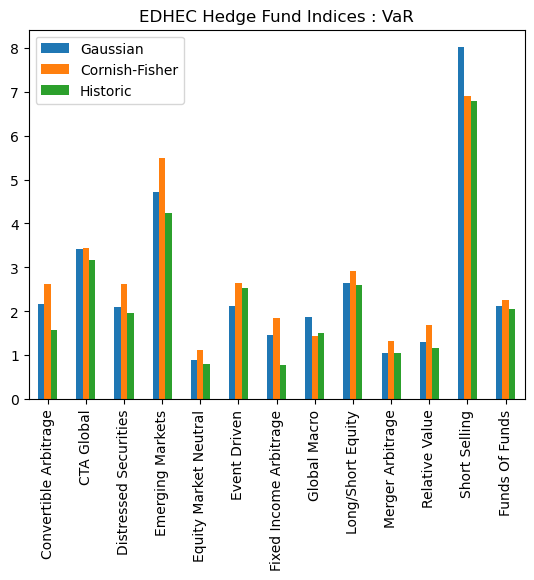

In [35]:
var_list = [var_gaussian(hfi), var_gaussian(hfi, modified =True), var_historic(hfi)]
comparison =pd.concat(var_list, axis=1)
comparison.columns =["Gaussian", "Cornish-Fisher", "Historic"]
comparison.plot.bar(title ="EDHEC Hedge Fund Indices : VaR")

### CVAR (Expected Shortfall)

##### perte moyenne au-delà de la VaR
##### Plus sévère que la VaR.
##### Le CVaR est une mesure plus robuste pour les risques extrêmes :
##### il résume les pertes moyennes des pires scénarios.
##### Le CVaR (Conditional Value at Risk), également appelé Expected Shortfall, mesure la perte moyenne attendue dans les pires scénarios (généralement les 5% de cas les plus défavorables). L'analyse des valeurs CVaR révèle des profils de risque distincts parmi les différentes stratégies de fonds hedge. 



In [ ]:
def cvar_historic(r, level=5):
    """
    Computes the Conditional VaR of Series or DataFrame
    """
    if isinstance(r, pd.Series):
        is_beyond = r <= -var_historic(r, level=level)
        return -r[is_beyond].mean()
    elif isinstance(r, pd.DataFrame):
        return r.aggregate(cvar_historic, level=level)
    else:
        raise TypeError("Expected r to be a Series or DataFrame")

In [37]:
cvar_historic(hfi) #CVaR at 5% represents the average loss in the worst 5% of cases.

Convertible Arbitrage     3.655000
CTA Global                4.126429
Distressed Securities     3.642857
Emerging Markets          7.236429
Equity Market Neutral     1.687857
Event Driven              3.833571
Fixed Income Arbitrage    2.825714
Global Macro              2.062857
Long/Short Equity         4.194286
Merger Arbitrage          1.914286
Relative Value            2.465000
Short Selling             9.682143
Funds Of Funds            3.320714
dtype: float64

##### Les fonds Short Selling présentent le CVaR le plus élevé (9,68%), indiquant que dans les 5% pires mois, cette stratégie subit en moyenne des pertes de près de 10%, reflétant son exposition extrême aux marchés haussiers. Globalement, cette hiérarchie du CVaR correspond aux caractéristiques fondamentales de chaque stratégie, les approches directionnelles comme le short selling étant naturellement plus exposées aux pertes extrêmes que les stratégies market neutres ou d'arbitrage.